You might have heard some of us or our PI talks about PCA. But what exactly that is? what do it do?


<br>    


# Dimensionality Reduction for High-Dimensional Data

In this notebook we will introduces three commonly used pattern-recognition / dimensionality-reduction methods for high-dimensional feature tables (e.g., LC-HRMS nontarget feature tables):

1. **PCA (Principal Component Analysis)** — unsupervised, linear. 
2. **PLS-DA (Partial Least Squares Discriminant Analysis)** — supervised, linear. 
3. **UMAP (Uniform Manifold Approximation and Projection)** — unsupervised, nonlinear. Brief overview only.

since we're just chemist and dont want to get into the math part, I will only introduce about the concepts and some simple code only. 

<br>

But first, what's `dimension reduction`?

usually when we work with data for plotting, we're looking at just x and y values. that's 2-dementions, or 2D. easy. 

3D? not much a problem as long as we can get a good angle to look at the 3D graph.


<Br>
but what if you have lots of columns of data, like LCMS which can even have thousands of peaks?

so we need to tranform the data somehow into either 2D or 3D so we as human as work with it more easily. 

you may ask, from thousands of columns reducing to 2 or 3 columns, dont we loss a lot of information?

well, this is the goal of the method: retain as much information as possible while reducing how much we need to work with.



<br>

note:

in this file, i will usually refer variables (individual peaks in our data) as feature.

# Principal Component Analysis (PCA)


PCA is a really common tool for exploratory purpose or looking at a complex data.

as mentioned before, we need to transform high demention data into a few only. in PCA, the new variable constructed is called the principal component, or PC. Each PC is a linear combination of the original features, which present the `directions of the data that explain a maximal amount of variance`. since more variance = more information (in the perfect world, but variance could come from batch effects or blank/noise signals)


The first PC (PC1) should capture the most variance within the data. the second PC (PC2) should capture the most of the remaining varaince, by being uncorrelated or orthogonal to PC1. PC3 continues the pattern, and so on. usually we stop at 3 as we can only visualize up to 3D. But percisely we had to rely on scree plot or cross-validation and determine by how much variance is explained.

<br>

### so, how does the "directions" come from?

Mechanically, PCA is finding the eigenvectors of the feature covariance matrix, and the corresponding eigenvalues tell you how much variance each eigenvector (PC) accounts for. You don't need the derivation to use this well — the important intuition is:

<br>
eigenvectors = directions <br>
eigenvalues = how much variance is along that direction. 

<br>

Note that in Stats, the `true loadings` are not what we used here but __eigenvectors multiplied by the square root of the eigenvalues__. This represents the actual correlation between the original variable and the PC score.

<br>

from the sklearn.decomposition.PCA you can find: 

- `pca.components_` gives the unit weights (often referred to loosely as loadings)
- `pca.explained_variance_ratio_` for the explained variance for each PC

<br>


after all the math, usually we care about a few things: 

1. Variance explained 

A `scree plot` is usually used for this, which is a bar graph of variance explained vs. PC number. This will tell you how many PC you need to capture enough variance in the data. 

2. visualizing the samples

a lot of time we want to see the groups of sample on PCA to tell if the groups are different or not. a `score plot`, which is PCx vs PCy scatter plot with each sample presented as a single data point.

3. the "loading"

when a PC is constructed, each feature has a coefficient that present the "weight" of the feature in this PC. higher absolute value of this means it contribute more to the variance. This is important for selecting features that's most important


<br><br>

#### what to keep in mind

PCA is scale-sensitive, which matters a lot for MS intensity data. what that means is, when you have peaks that intensity (or area) has large range like from 0 to 1E7, while other may be relatively small from 0 to 1E5, the larger peaks will dominate the varaiance. 

most common way is to do standardize scaling, i.e., make mean = 0 abd standard deviation = 1, with `sklearn.preprocessing.StandardScaler`. this method is also used in other machine learning techniques like K-mean, and SVM. read more in later section as there's assumption about this.


<br>
sometime you may choose to use log-tranformation. this does the job of compressing the range of data, but you still need to deal with the mean subtraction after.








Now enough information, lets look into the code...




First of all,  you need to look at your data first. 

we need peaks in the column and sample in the row, but mass spec data is usually reversed, which means you need to transpose your data first. so in that sense, we expected our data to be in the format of X (m by n, or sample x feature) and y (m number of samples). in most of the cases your y is simply the group label column or the index when put into a DataFrame 

<br><br>


 machine learning codes you see only usually use the cap X for the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# 1. Mocking  LC-MS Data
# 40 samples (20 Wood Smoke, 20 Plastic Smoke), 3000 m/z features
# ---------------------------------------------------------

# np.random.seed(99)
# n_features = 3000

# # Generating overlapping background noise, with a few distinct features
# wood_data = np.random.rand(20, n_features) * 50
# plastic_data = np.random.rand(20, n_features) * 50

# # Injecting 'biomarkers' (features that actually differ between groups)
# wood_data[:, 10:20] += 30  # Wood has higher abundance in features 10-19
# plastic_data[:, 40:50] += 30 # Plastic has higher abundance in features 40-49

# data = np.vstack((wood_data, plastic_data))
# labels = ['Wood'] * 20 + ['Plastic'] * 20

# df = pd.DataFrame(data, columns=[f'mz_{i}' for i in range(n_features)])
# df['Condition'] = labels
# ---------------------------------------------------------
# 1. Mocking Aerosolomics LC-MS Data
# 40 samples (20 Wood Smoke, 20 Plastic Smoke), 3000 m/z features
# ---------------------------------------------------------
np.random.seed(666)
n_features = 3000

# Generating overlapping background noise, with a few distinct features
wood_data = np.random.rand(20, n_features) * 50
plastic_data = np.random.rand(20, n_features) * 50

# Injecting 'markers' (features that actually differ between groups)
wood_data[:, 10:20] += 50  # Wood has higher abundance in features 10-19
plastic_data[:, 40:50] += 90 # Plastic has higher abundance in features 40-49

data = np.vstack((wood_data, plastic_data))
labels = ['Wood'] * 20 + ['Plastic'] * 20

df = pd.DataFrame(data, columns=[f'mz_{i}' for i in range(n_features)])
df['Condition'] = labels
df.head()

,mz_0,mz_1,mz_2,mz_3,mz_4,mz_5,mz_6,mz_7,mz_8,mz_9,...,mz_2991,mz_2992,mz_2993,mz_2994,mz_2995,mz_2996,mz_2997,mz_2998,mz_2999,Condition
0,35.021856,42.209332,33.825717,36.392903,47.572898,0.635160,20.679385,2.440640,4.996428,25.403315,...,46.969699,24.180538,36.724798,23.837869,25.358621,47.631823,42.611929,28.111804,49.827474,Wood
1,48.653980,9.234075,33.145363,16.832462,19.212027,14.775104,34.097319,29.804100,5.197751,4.643983,...,44.032694,42.489635,9.864173,33.384433,24.720277,34.409882,6.056142,48.361055,2.200809,Wood
2,16.959629,17.371588,4.730833,27.013753,5.867399,25.398873,10.196279,23.577001,19.825878,37.914785,...,2.189506,19.534775,19.598695,30.306780,15.207183,5.755797,7.306331,15.670388,21.641737,Wood
3,44.322745,6.470212,32.465177,38.868992,33.575617,42.626241,5.590541,44.170210,27.278789,24.316211,...,22.480251,39.796866,33.485537,17.713637,18.070320,39.318601,1.987918,22.968641,13.758203,Wood
4,14.770406,19.350395,27.776836,43.347680,27.417081,19.765422,18.876545,2.967895,36.776625,15.043114,...,9.062016,32.882411,24.366240,19.582354,22.197581,28.704000,38.863109,6.468342,44.549368,Wood


In [2]:
X = df.drop('Condition', axis=1)
y = np.array([0 if label == 'Wood' else 1 for label in df['Condition']])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=10)
scores = pca.fit_transform(X_scaled)

scores_df = pd.DataFrame(
    scores,
    columns=[f"PC{i+1}" for i in range(scores.shape[1])],
    index=X.index,)
scores_df["group"] = y

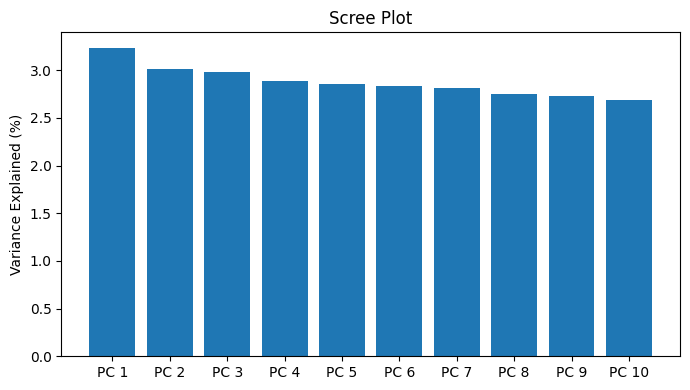

In [3]:
# the scree plot
explained_var = pca.explained_variance_ratio_ * 100

fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.bar(["PC " + str(i) for i in range(1, len(explained_var) + 1)], explained_var)
ax1.set_ylabel("Variance Explained (%)")

plt.title("Scree Plot")
plt.tight_layout()
plt.show()

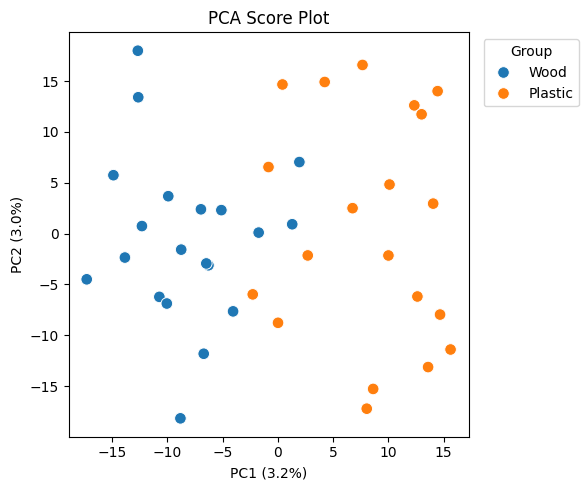

In [4]:
# the score plot
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=scores_df, x="PC1", y="PC2", hue=labels, s=70)
plt.xlabel(f"PC1 ({explained_var[0]:.1f}%)")
plt.ylabel(f"PC2 ({explained_var[1]:.1f}%)")
plt.title("PCA Score Plot")
plt.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

note that the explained variance is low as we just generated random data... 

in principle you want the combined explained variance to be over 50% for PC1 + PC2 (though not a requirement and oftenly complex data like LCMS may has low explained variance)

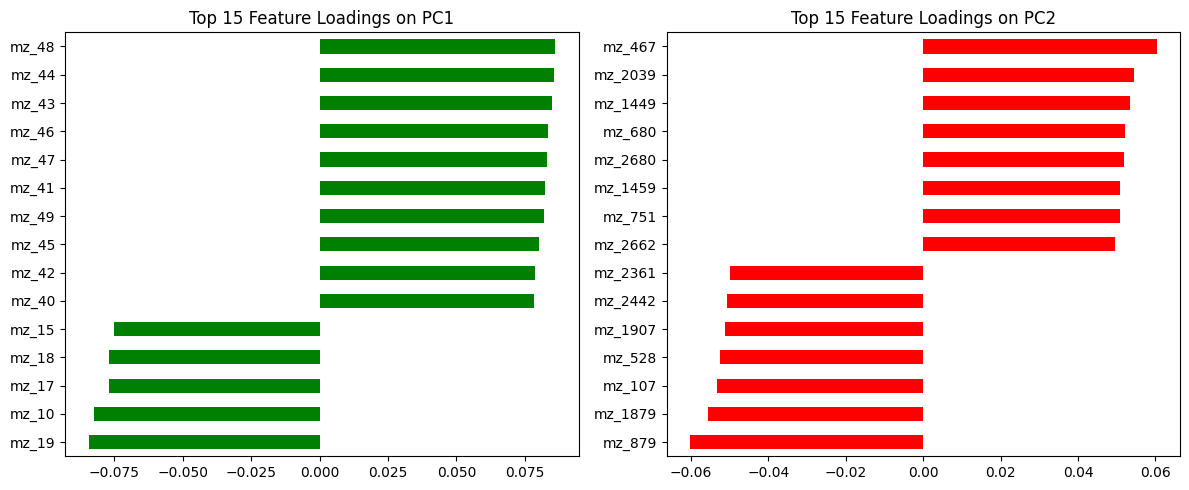

In [5]:
# the loading, note that this is not the true loading as in stats
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.components_.shape[0])],
    index=X.columns,
)

top_n = 15
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(top_n).index
top_pc2 = loadings["PC2"].abs().sort_values(ascending=False).head(top_n).index

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
loadings.loc[top_pc1, "PC1"].sort_values().plot.barh(ax=axes[0], color="green")
axes[0].set_title(f"Top {top_n} Feature Loadings on PC1")

loadings.loc[top_pc2, "PC2"].sort_values().plot.barh(ax=axes[1], color="red")
axes[1].set_title(f"Top {top_n} Feature Loadings on PC2")

plt.tight_layout()
plt.show()

In [6]:
## to pack them in to a fuction

def pareto_scale(X):
    """Pareto scaling: mean-center, then divide by sqrt(std) instead of std.
    Standard default in metabolomics PCA/PLS-DA (van den Berg et al. 2006) —
    less aggressive than autoscaling, doesn't blow up noisy near-zero features
    the way StandardScaler can on sparse MS data."""
    X = np.asarray(X, dtype=float)
    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=1)
    std[std == 0] = 1  # avoid div-by-zero on constant/all-zero features
    return (X - mean) / np.sqrt(std)

def run_pca(df, log_transform=False, feature_in_row=True, n_components=4,
            scaling="standard",           # "standard", "pareto", or "none"
            skip_standardscaler=False):    # deprecated, kept for backward compat -> maps to scaling="none"
            
    df = df.copy()
    df.fillna(0, inplace=True)
    if not feature_in_row:
        if "mz" in df.columns:
            df.set_index("mz", inplace=True)
        df_t = df.T
    else:
        df_t = df

    if log_transform:
        df_t = np.log10(df_t + 1)

    df_t.sort_index(inplace=True)

    if skip_standardscaler:
        scaling = "none"

    if scaling == "standard":
        X = StandardScaler().fit_transform(df_t)
    elif scaling == "pareto":
        X = pareto_scale(df_t)
    elif scaling == "none":
        X = df_t.values
    else:
        raise ValueError(f"Unknown scaling option: {scaling!r}. Use 'standard', 'pareto', or 'none'.")

    pca = PCA(n_components=n_components)
    x_pca = pca.fit_transform(X)

    x_pca_df = pd.DataFrame(x_pca,
                            columns=[f'PC{i+1}' for i in range(n_components)],
                            index=df_t.index)
    
    explained_variance = pca.explained_variance_ratio_
    
    loadings = pd.DataFrame(pca.components_.T,
                            index=df.index,
                            columns=["PC" + str(i) for i in range(1, n_components+1)])
    
    pca_results = {"x_pca": x_pca_df,
                "loadings": loadings,
                "explained_variance": explained_variance,
                "scaling": scaling
                }

    return x_pca_df, pca_results

def plot_pca(ax, df, name, group, sample_types, feature_in_row=False, log_transform=True, n_components=2):
    x_pca, pca_results = run_pca(df, log_transform=log_transform, feature_in_row=feature_in_row, n_components=n_components)
    comp_df = pca_results["loadings"]
    comp_df = pd.concat([df.copy(),comp_df.T], axis=1)
    
    x_pca.reset_index(inplace=True)
    x_pca["group"] = group
    x_pca["type"] = sample_types

    sns.scatterplot(data=x_pca, x="PC1", y="PC2", hue="group", style="type" ,ax=ax, s=75, alpha=0.85, legend='auto')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

    axes[i].set_title(name)
    return x_pca, comp_df


### So PCA looks nice, but what we should be careful about?


##### the arch effect (or horseshoe effect)

This happens your PCA plot has a U- or arc shape distribution of samples. 


If samples follow a continuous chemical trajectory/gradient (e.g., reaction time, combustion temperature, dilution series), the true manifold is curved in feature space. PCA tries to flatten a 1D curve onto linear axes, forcing the curve to split across PC1 and PC2.

how to know? 

you can try to see if PC2 can be approximate by a quadratic function of PC1, i.e., ` PC2 = a * PC1 ^2 + b`. if the fitting is good, then it's mostly likely you have the arch effect.


so what happened? 

1. there could be extreme concentration or signal differences. this could happen with a clean blank vs heavily loaded sample
2. progression in sample, such as samples of burn from begining to smouldering which some compounds appear or disappear
3. similar to point 2, your insturment may produce something similar due to contamination or drifting


is this really mean your data is bad? __not always__, but worth examine the data again


potential solution:
1. see if there's any extreme cases/peaks in the sample, then rethink about normalization (since we always do stadardscalor, it may not be the best way), sometime log tranformation may help. or if blank is the issue, remove it and plot again.

2. PCA simply may not be the right tool to use, try other non-linear methods

### about standardscaler 


standardscaler is normally used in PCA (like the standard way to use it in general), espeically the examples usually came from something like biological (weight, height, certain traits etc). but standardscaler works for __normal distributed__ data and it's __sensitive to outliers__. 

so if you know your data is not going to be normally distributed, it's good to consider using other scalers.


there's a good comparison about scalers: 

https://scikit-learn.org/stable/auto_examples/preprocessing/plot_all_scaling.html#plot-all-scaling-standard-scaler-section

# Principal Coordinates Analysis (PCoA)


instead of feeding the standardized data to use Euclidean distance, we can of course do other math... this is where we do PCoA, or sometime refers to `Multi-dimensional Scaling` or MDS as in the sklearn package. 

what it means by "distance" is really "how different are things?". or imagine it's "how far two things are" but in the mathematical world


if we do PCoA with Euclidean  distence, this is basically PCA
the key difference are:

1. PCoA works backwards, which we compute the distance first, then get to low demensions that preserve the distance
2. PCA is only Euclidean, where PCoA accepts others

so in that sense, we actually "fix" the distance matrix 

### Bray-Curtis

this is basically "what fraction of your total signal is different". It only cares about the shared features' relative sizes — it doesn't do anything special about zeros, it just naturally down-weights them since a feature that's absent in both contributes nothing to the difference.


- still kind of linear which tends to be dominated by your highest-abundance features unless you've already normalized hard.
- care less about rare features
- this is more common in ecology/microbiome 



### Hellinger 


this is similart to PCA which also uses Euclidean distence, but with square root and normalize by sum of the data first. 

- it compresses large values and stretches apart small ones, which specifically fixes the "double-zero problem": in raw Euclidean distance, two samples that both lack a rare compound look artificially similar (they agree on a zero), but after square-rooting, small nonzero values are pulled apart from true zeros instead of getting crushed toward them.
-  do square root first on data +  PCA = PCoA with Hellinger distance matrix
- may use when you suspect there's rare and low abundance feature that are actually important 

In [7]:
def hellinger_transform(df):
    rel_abundance = df.div(df.sum(axis=1), axis=0)
    hellinger = np.sqrt(rel_abundance)

    return hellinger

read the sklearn documentation here:

https://scikit-learn.org/stable/modules/manifold.html#multidimensional-scaling


https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html#sklearn.manifold.MDS

<br>

for the distance metrix calculation, you might want to check out pdist page :https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.pdist.html






In [8]:
from sklearn.manifold import MDS
from scipy.spatial.distance import pdist, squareform
import pandas as pd

# Assuming 'df' has samples as rows and features as columns.
# (If your features are in rows, use df.T instead)
def run_pcoa(df, sample_in_row=True, log_transform=True, metric='braycurtis'):

    df.fillna(0,inplace=True)
    if not sample_in_row:
        df_t = df.T
    else:
        df_t = df
        
    if log_transform:
        df_t = np.log10(df_t + 1)

    df_t = df_t.sort_index()


    bc_distances = pdist(df_t.values, metric=metric)
    distance_matrix = squareform(bc_distances)

    pcoa_model = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    pcoa_coordinates = pcoa_model.fit_transform(distance_matrix)

    pcoa_df = pd.DataFrame(data=pcoa_coordinates, columns=['PCo1', 'PCo2'])
    pcoa_df.index = df_t.index 
    return pcoa_df

def plot_pcoa_results(pcoa_df, grouping_list, ax, title):
    sns.scatterplot(data=pcoa_df, 
                    x="PCo1",
                    y="PCo2",
                    hue=grouping_list,
                    s=50, alpha=0.85,
                    ax=ax)
    ax.set_title(title)




# Partial least squares discriminant analysis (PLS-DA)




recommended reading:

https://doi.org/10.1002/cem.2609


Top 10 Most Important m/z Features:
   Feature  Coefficient
45   mz_45     0.005252
49   mz_49     0.005230
46   mz_46     0.005220
42   mz_42     0.005205
41   mz_41     0.005198
40   mz_40     0.005175
47   mz_47     0.005170
44   mz_44     0.005148
48   mz_48     0.005133
43   mz_43     0.005113


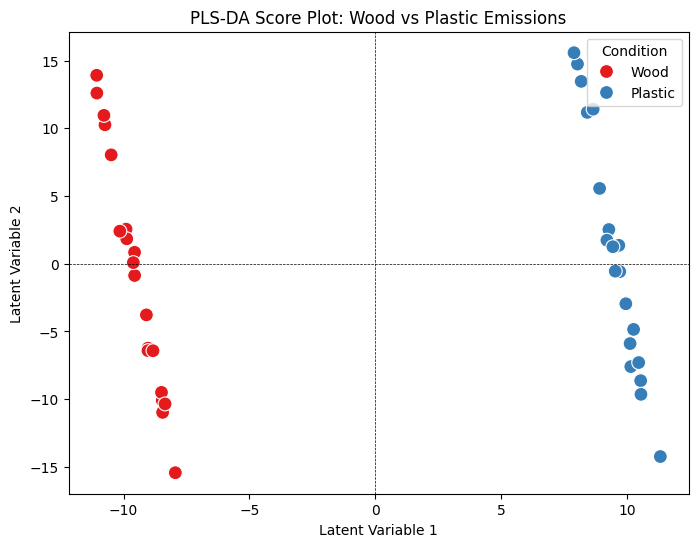

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import accuracy_score
# ---------------------------------------------------------
# 1. we use the previous same mock data
# ---------------------------------------------------------
df = df.copy()
condition = df["Condition"].copy()

# ---------------------------------------------------------
# 2. Preprocessing & Label Encoding
# ---------------------------------------------------------
X = df.drop('Condition', axis=1)

# Supervised models require numerical labels (Wood = 0, Plastic = 1)
Y = np.array([0 if label == 'Wood' else 1 for label in df['Condition']])

# Scaling is mandatory for MS data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------------------------------------------
# 3. Fitting the PLS-DA Model
# ---------------------------------------------------------
# We extract 2 "Latent Variables" (similar to Principal Components)
pls = PLSRegression(n_components=2)
pls.fit(X_scaled, Y)

# Get the scores (coordinates for the scatter plot)
X_scores= pls.x_scores_
df['LV1'] = X_scores[:, 0]
df['LV2'] = X_scores[:, 1]

# ---------------------------------------------------------
# 4. Finding Important Features (Coefficients)
# ---------------------------------------------------------
# Extract the regression coefficients. The larger the absolute value, 
# the more important the m/z feature is for separating the groups.
coefficients = pls.coef_.ravel()

# Create a DataFrame to rank the features
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Absolute_Importance': np.abs(coefficients)
})

# Sort by most important
top_features = feature_importance.sort_values(by='Absolute_Importance', ascending=False).head(10)
print("Top 10 Most Important m/z Features:")
print(top_features[['Feature', 'Coefficient']])

# ---------------------------------------------------------
# 5. Plotting the PLS-DA Scores
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(x='LV1', y='LV2', hue='Condition', data=df, palette='Set1', s=100)
plt.title('PLS-DA Score Plot: Wood vs Plastic Emissions')
plt.xlabel('Latent Variable 1')
plt.ylabel('Latent Variable 2')
plt.axhline(0, color='black', linestyle='--', linewidth=0.5)
plt.axvline(0, color='black', linestyle='--', linewidth=0.5)
plt.show()

In [10]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

# Use only the real feature columns. (The PLS-DA cell above added LV1/LV2 to df,
# so never use "everything except Condition" as X.)
feature_cols = [c for c in df.columns if c.startswith("mz_")]
X_val = df[feature_cols].values
y_val = np.array([0 if label == "Wood" else 1 for label in df["Condition"]])

def make_plsda(n_components):
    # scaling inside the pipeline -> re-fit on the training part of every CV fold
    return make_pipeline(StandardScaler(), PLSRegression(n_components=n_components, scale=False))

def cv_q2(X, y, n_components, n_splits=5, n_repeats=5, seed=0):
    """Repeated stratified k-fold. Returns Q2, accuracy, AUC (averaged over repeats)."""
    q2s, accs, aucs = [], [], []
    tss = np.sum((y - y.mean()) ** 2)
    for r in range(n_repeats):
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed + r)
        y_pred = cross_val_predict(make_plsda(n_components), X, y, cv=cv).ravel()
        press = np.sum((y - y_pred) ** 2)
        q2s.append(1 - press / tss)
        accs.append(np.mean((y_pred > 0.5) == y))
        aucs.append(roc_auc_score(y, y_pred))
    return np.mean(q2s), np.mean(accs), np.mean(aucs)

       R2Y     Q2  CV_accuracy  CV_AUC
LVs                                   
1    0.991  0.252         0.94   0.986
2    1.000  0.255         0.93   0.981
3    1.000  0.255         0.93   0.982
4    1.000  0.254         0.93   0.982
5    1.000  0.254         0.93   0.982
6    1.000  0.254         0.93   0.982
7    1.000  0.254         0.93   0.982
8    1.000  0.254         0.93   0.982


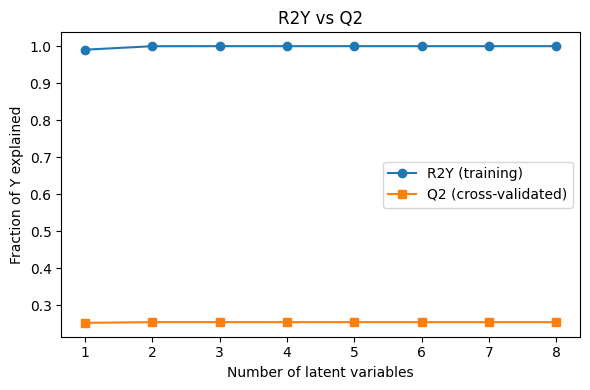

In [11]:
# 1. choose the number of latent variables
max_lv = 8
rows = []
for k in range(1, max_lv + 1):
    q2, acc, auc = cv_q2(X_val, y_val, k)
    # R2Y: on the training data (always optimistic)
    m = make_plsda(k).fit(X_val, y_val)
    r2y = 1 - np.sum((y_val - m.predict(X_val).ravel()) ** 2) / np.sum((y_val - y_val.mean()) ** 2)
    rows.append({"LVs": k, "R2Y": r2y, "Q2": q2, "CV_accuracy": acc, "CV_AUC": auc})

lv_table = pd.DataFrame(rows).set_index("LVs")
print(lv_table.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lv_table.index, lv_table["R2Y"], "o-", label="R2Y (training)")
ax.plot(lv_table.index, lv_table["Q2"], "s-", label="Q2 (cross-validated)")
ax.set_xlabel("Number of latent variables")
ax.set_ylabel("Fraction of Y explained")
ax.set_title("R2Y vs Q2")
ax.legend()
plt.tight_layout()
plt.show()

**How to read this:** R2Y keeps climbing as you add LVs, but Q² stops improving (or drops) once the model starts fitting noise. Pick the number of LVs where Q² peaks or levels off, and prefer the smaller one if they are close. (In the mock data Q² is flat from the first LV on, so 1 or 2 LVs is enough; extra LVs only fit noise.) A big gap between R2Y and Q² means overfitting.

LVs used: 1
Real labels     : Q2 = 0.252, CV accuracy = 0.940, CV AUC = 0.986
Shuffled labels : Q2 = -0.013 +/- 0.046, accuracy = 0.498 +/- 0.099
Permutation p-value: Q2 p = 0.0050, accuracy p = 0.0050


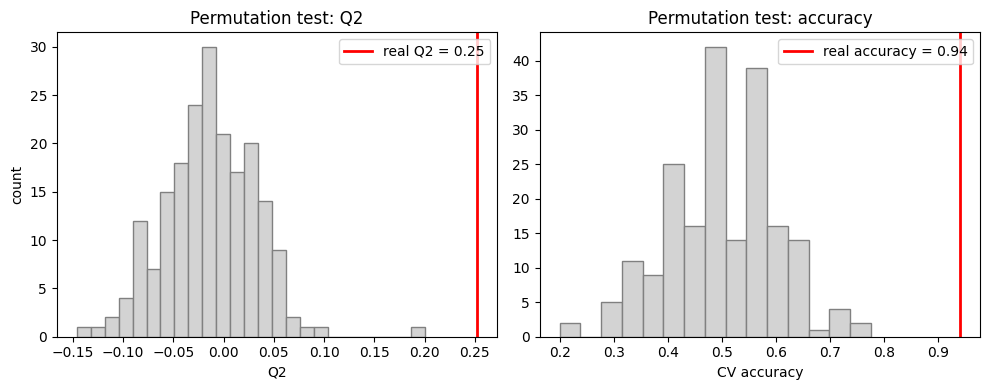

In [12]:
# 2. permutation test: is the real Q2 better than what random labels give?
# smallest number of LVs whose Q2 is within 0.01 of the best one (or set n_lv by hand)
n_lv = int(lv_table.index[lv_table["Q2"] >= lv_table["Q2"].max() - 0.01][0])
n_perm = 200
rng = np.random.default_rng(42)

q2_real, acc_real, auc_real = cv_q2(X_val, y_val, n_lv)

q2_perm, acc_perm = [], []
for i in range(n_perm):
    y_shuf = rng.permutation(y_val)
    q2, acc, _ = cv_q2(X_val, y_shuf, n_lv, n_repeats=1, seed=i)
    q2_perm.append(q2)
    acc_perm.append(acc)
q2_perm, acc_perm = np.array(q2_perm), np.array(acc_perm)

# +1 so the p-value is never exactly 0
p_q2 = (np.sum(q2_perm >= q2_real) + 1) / (n_perm + 1)
p_acc = (np.sum(acc_perm >= acc_real) + 1) / (n_perm + 1)

print(f"LVs used: {n_lv}")
print(f"Real labels     : Q2 = {q2_real:.3f}, CV accuracy = {acc_real:.3f}, CV AUC = {auc_real:.3f}")
print(f"Shuffled labels : Q2 = {q2_perm.mean():.3f} +/- {q2_perm.std():.3f}, accuracy = {acc_perm.mean():.3f} +/- {acc_perm.std():.3f}")
print(f"Permutation p-value: Q2 p = {p_q2:.4f}, accuracy p = {p_acc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(q2_perm, bins=25, color="lightgray", edgecolor="gray")
axes[0].axvline(q2_real, color="red", lw=2, label=f"real Q2 = {q2_real:.2f}")
axes[0].set_xlabel("Q2"); axes[0].set_ylabel("count"); axes[0].legend()
axes[0].set_title("Permutation test: Q2")

axes[1].hist(acc_perm, bins=15, color="lightgray", edgecolor="gray")
axes[1].axvline(acc_real, color="red", lw=2, label=f"real accuracy = {acc_real:.2f}")
axes[1].set_xlabel("CV accuracy"); axes[1].legend()
axes[1].set_title("Permutation test: accuracy")
plt.tight_layout()
plt.show()

**How to read this:** the grey histogram is what the method gives you when there is *no real relationship* between the data and the labels. If the red line sits clearly outside the grey, the model is picking up real structure. If it sits inside the grey, the separation in the score plot is not trustworthy. Note that random labels usually do not give Q² = 0 or 50% accuracy. This is exactly why we need the comparison.

Also report the permutation p-value together with Q², and don't use the score plot alone.

Features with VIP > 1: 848 of 3000
Feature      VIP
  mz_45 5.482941
  mz_41 5.450979
  mz_46 5.450837
  mz_47 5.443535
  mz_49 5.441020
  mz_42 5.427418
  mz_48 5.410643
  mz_44 5.399126
  mz_43 5.383593
  mz_40 5.374562
  mz_19 5.175338
  mz_15 5.091256
  mz_11 5.058651
  mz_10 5.000114
  mz_17 4.970838


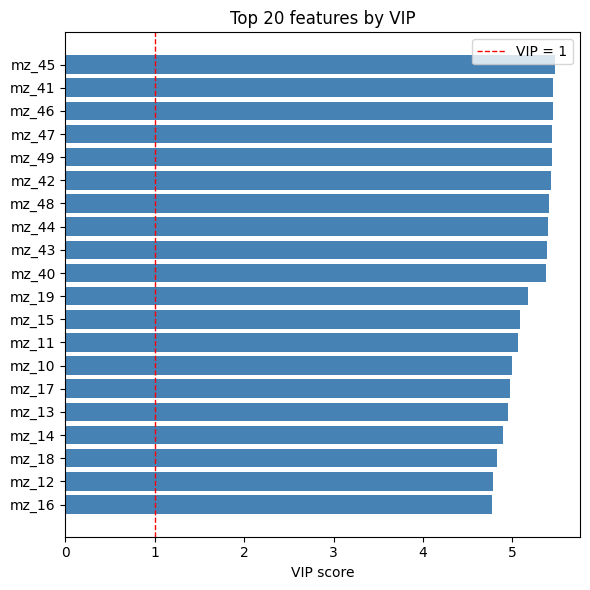

In [13]:
# 3. VIP scores: which features drive the separation?
def vip_scores(pls):
    """Variable Importance in Projection from a fitted PLSRegression."""
    t = pls.x_scores_          # (n_samples, n_lv)
    w = pls.x_weights_         # (n_features, n_lv)
    q = pls.y_loadings_        # (n_targets, n_lv)
    p = w.shape[0]
    ss = np.sum(q ** 2, axis=0) * np.sum(t ** 2, axis=0)   # Y variance explained by each LV
    w_norm = w / np.linalg.norm(w, axis=0)
    return np.sqrt(p * (w_norm ** 2 @ ss) / ss.sum())

final_model = make_plsda(n_lv).fit(X_val, y_val)
vip = vip_scores(final_model.named_steps["plsregression"])

vip_df = pd.DataFrame({"Feature": feature_cols, "VIP": vip}).sort_values("VIP", ascending=False)
print("Features with VIP > 1:", int((vip_df["VIP"] > 1).sum()), "of", len(vip_df))
print(vip_df.head(15).to_string(index=False))

top = vip_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(6, 6))
ax.barh(top["Feature"], top["VIP"], color="steelblue")
ax.axvline(1, color="red", ls="--", lw=1, label="VIP = 1")
ax.set_xlabel("VIP score"); ax.set_title("Top 20 features by VIP"); ax.legend()
plt.tight_layout()
plt.show()

**How to read this:** VIP > 1 is the usual (loose) cut-off, since the average squared VIP is 1. With 3000 features, many noise features will still pass VIP > 1, so treat it as a ranking, not a significance test. For real data, follow up with the raw intensities of the top features (boxplots), and check that the ranking is stable across CV folds or repeated runs.

In this mock data we *know* the true markers: mz_10 to mz_19 (Wood) and mz_40 to mz_49 (Plastic). The check below shows how many of the top-ranked features are the real ones.

In [14]:
# sanity check on the mock data only (you won't have this ground truth with real samples)
true_markers = {f"mz_{i}" for i in list(range(10, 20)) + list(range(40, 50))}
for n in (10, 20, 50):
    hits = len(set(vip_df.head(n)["Feature"]) & true_markers)
    print(f"top {n:>2} VIP features: {hits} are true markers (out of {len(true_markers)} total)")

top 10 VIP features: 10 are true markers (out of 20 total)
top 20 VIP features: 20 are true markers (out of 20 total)
top 50 VIP features: 20 are true markers (out of 20 total)


# UMAP (Uniform Manifold Approximation and Projection)


documentation: https://umap-learn.readthedocs.io/en/latest/


the publication are here: 

https://arxiv.org/abs/1802.03426

McInnes, L, Healy, J, UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction, ArXiv e-prints 1802.03426, 2018. 

<Br>

https://doi.org/10.1038/s43586-024-00363-x


Healy, J., McInnes, L. Uniform manifold approximation and projection. Nat Rev Methods Primers 4, 82 (2024)

<Br>





UMAP is interesting one, but a lot more complex (and new!)


so far we are mostly talking about linear method, and UMAP is acutally non-linear. 

there are 3 assumptions:

1. The data is uniformly distributed on a Riemannian manifold
2. The Riemannian metric is locally constant (or can be approximated as such)
3. The manifold is locally connected.


UMAP is generally better than PCA or PCoA when the underlying structure of the data is non-linear, multi-clustered, or continuous along a complex trajectory (as we explained in the arch effect previously).

sometimes if there are too many groups, PCA might struggle as there can be groups that have large variance and thus the other groups ended up cluster or overlapping simply due to the dominant features. UMAP focuses on local neighborhoods (which is controlled by n_neighbors) which may produce more distinct clusters

similar to PCoA, you can select how you want to claculate the distance matrix. though PCoA is still linear method where UMAP is non-linear. 


yet, PCA is still the best for exploratory usage while you may try UMAP with more understanding (or found issue with PCA...)

### what to know before running 

there are some parameter that matters:

#### n_neighbors

Low values Focuses heavily on local structure/fine-grained sub-clusters, but may break continuous gradients into fragmented islands.

High values Focuses on global relationships across the whole dataset, acting more like PCA or large-scale manifold mapping.


#### min_dist

Controls how closely points are allowed to cluster together in the 2D plot.

Small values Produces dense, tight, discrete clumps (useful for distinct sample classifications).

Large values Spreads points out more smoothly (useful if you are looking at continuous environmental gradients or dilution series).

#### metric 

Unlike standard PCA, UMAP natively allows you to pass different distance metrics directly, such as 'cosine', 'manhattan', 'correlation', or 'canberra'

### how it's different


1. there's no explained variance since it's non-linear

2. there's no loadings since it's non-linear


3. there's random state ( which means that you need to set it for reproducible results)

you do need to install the package by 

`pip install umap-learn`

C:\Users\wayne\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


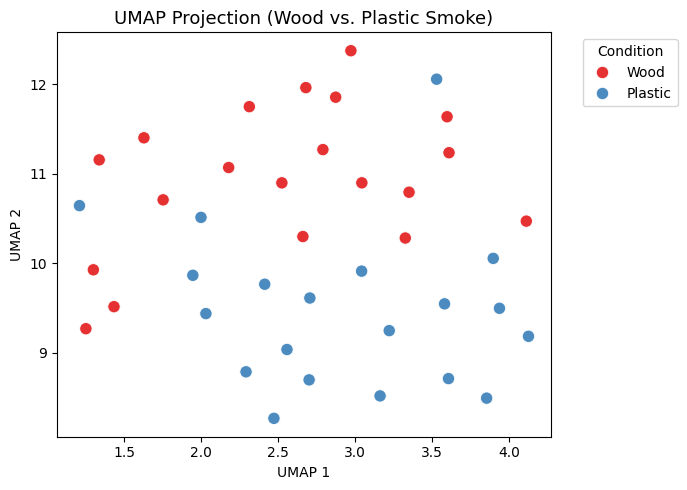

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler

df = df.copy()
condition = df["Condition"].copy()
X = df.drop('Condition', axis=1)
Y = np.array([0 if label == 'Wood' else 1 for label in df['Condition']])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ---------------------------------------------------------
# 1. Initialize and Fit UMAP
# ---------------------------------------------------------
# X_scaled is your standardized (or log-transformed/Pareto-scaled) feature matrix
reducer = umap.UMAP(
    n_components=2,       # Number of dimensions to reduce down to
    n_neighbors=15,       # Balances local vs. global structure
    min_dist=0.1,         # Controls how tightly points pack together
    metric='euclidean',   # Distance metric (can be 'cosine', 'braycurtis', etc.)
    random_state=42       # Ensures reproducible layout
)

# Fit and transform your scaled sample matrix
umap_embeddings = reducer.fit_transform(X_scaled)

# ---------------------------------------------------------
# 2. Put Results into a DataFrame
# ---------------------------------------------------------
umap_df = pd.DataFrame(umap_embeddings, columns=['UMAP1', 'UMAP2'], index=X.index)
umap_df['Condition'] = df['Condition']

# ---------------------------------------------------------
# 3. Plot the Embedding
# ---------------------------------------------------------
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='Condition',
    palette='Set1',
    s=80,
    alpha=0.9
)

plt.title('UMAP Projection (Wood vs. Plastic Smoke)', fontsize=13)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()